# Proyecto Primer Corte — Clasificación Multimodal
## Guitarra | Acordeón | Batería

**Pasos:**
1. Extracción de características (imagen + audio)
2. Unificación y escalamiento
3. Reducción de dimensionalidad con PCA
4. Clasificación con KNN
5. Evaluación del modelo

---
## Imports y configuración

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from skimage.feature import hog, local_binary_pattern
from skimage import color, transform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Rutas ────────────────────────────────────────────────────────
RUTA_IMAGENES    = Path("Dataset") / "imagenes_filtradas"
RUTA_AUDIO_NPZ   = Path("Dataset") / "Caracteristicas" / "matriz_resumen.npz"

INSTRUMENTOS = {
    "Guitarra": 0,
    "Acordeon": 1,
    "Bateria":  2
}

# ── Parámetros de imagen ─────────────────────────────────────────
IMG_SIZE   = (128, 128)   # todas las imágenes se redimensionan a este tamaño
LBP_RADIO  = 3            # radio de vecindad para LBP
LBP_PUNTOS = 24           # número de puntos vecinos para LBP (8 * radio)

print("Configuración lista.")

Configuración lista.


---
## Extracción de características de imagen

### ¿Por qué HOG + LBP?

Las imágenes son fotos reales de instrumentos con fondos variados, por lo que necesitamos descriptores robustos que no dependan del color de fondo.

- **HOG (Histogram of Oriented Gradients):** Captura la **forma y los bordes** del instrumento dividiendo la imagen en celdas y calculando la dirección de los gradientes en cada una. Es muy efectivo para distinguir siluetas: una guitarra tiene una forma muy distinta a una batería o un acordeón, incluso con fondos diferentes.

- **LBP (Local Binary Patterns):** Captura la **textura** local de la imagen. Las cuerdas de una guitarra, los botones de un acordeón y los parches de una batería tienen patrones de textura claramente distintos que LBP puede representar de forma compacta.

Combinar ambos descriptores permite representar tanto la forma global como la textura local del instrumento en un único vector.

In [28]:
def extraer_hog_lbp(ruta_imagen):
    """
    Lee una imagen, la redimensiona a IMG_SIZE y extrae:
      - Descriptor HOG  (forma y bordes)
      - Histograma LBP  (textura local)
    Devuelve un vector concatenado [HOG | LBP] o None si hay error.
    """
    try:
        # Leer y redimensionar
        img = cv2.imread(str(ruta_imagen))
        img = cv2.resize(img, IMG_SIZE)

        # Convertir a escala de grises (HOG y LBP trabajan en gris)
        gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # ── HOG ──────────────────────────────────────────────────
        # pixels_per_cell: tamaño de cada celda local
        # cells_per_block: cuántas celdas forman un bloque (normalización)
        # orientations:    número de direcciones de gradiente a considerar
        descriptor_hog = hog(
            gris,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        # ── LBP ──────────────────────────────────────────────────
        # method='uniform': solo considera patrones uniformes (más robusto)
        lbp = local_binary_pattern(gris, LBP_PUNTOS, LBP_RADIO, method='uniform')

        # Convertir LBP a histograma normalizado
        n_bins = LBP_PUNTOS + 2
        histograma_lbp, _ = np.histogram(
            lbp.ravel(),
            bins=n_bins,
            range=(0, n_bins),
            density=True   # normalizar para que sea independiente del tamaño
        )

        # ── Concatenar HOG + LBP ─────────────────────────────────
        vector = np.concatenate([descriptor_hog, histograma_lbp])
        return vector

    except Exception as e:
        print(f"  ⚠ Error en {ruta_imagen.name}: {e}")
        return None


print("Función de extracción de imagen lista.")

Función de extracción de imagen lista.


## Filtrado de imágenes con Inteligencia Artificial (CLIP)

Para mejorar la calidad del dataset, seleccionando solo 500 imagenes por caracteristica, se utilizó un filtrado inteligente basado en **CLIP** (Contrastive Language-Image Pre-training), un modelo de inteligencia artificial desarrollado por OpenAI. CLIP fue entrenado con millones de pares de imágenes y descripciones de texto, lo que le permite entender el contenido visual de una imagen y compararlo con descripciones escritas en lenguaje natural.

Consideramos que el resultado fue satisfactorio, como se puede ver en las imagenes filtradas

In [29]:
# ── Procesar todas las imágenes ───────────────────────────────────
lista_img   = []
labels_img  = []

for nombre, etiqueta in INSTRUMENTOS.items():
    carpeta  = RUTA_IMAGENES / nombre
    
    # glob case-insensitive: evita duplicados por mayúsculas/minúsculas
    archivos = sorted(carpeta.glob("*.JPG"))

    print(f"\n{nombre}: {len(archivos)} imágenes encontradas")

    for i, archivo in enumerate(archivos):
        vec = extraer_hog_lbp(archivo)
        if vec is None:
            continue
        lista_img.append(vec)
        labels_img.append(etiqueta)

        if (i + 1) % 100 == 0:
            print(f"  [{i+1}/{len(archivos)}] procesadas")

    print(f"  ✓ {nombre} completado")

X_imagen  = np.array(lista_img)    # (num_audios, dim_hog+lbp)
y_imagen  = np.array(labels_img)

print(f"\nMatriz de características de imagen: {X_imagen.shape}")
print(f"  → {X_imagen.shape[1]} características por imagen (HOG + LBP)")


Guitarra: 500 imágenes encontradas
  [100/500] procesadas
  [200/500] procesadas
  [300/500] procesadas
  [400/500] procesadas
  [500/500] procesadas
  ✓ Guitarra completado

Acordeon: 500 imágenes encontradas
  [100/500] procesadas
  [200/500] procesadas
  [300/500] procesadas
  [400/500] procesadas
  [500/500] procesadas
  ✓ Acordeon completado

Bateria: 500 imágenes encontradas
  [100/500] procesadas
  [200/500] procesadas
  [300/500] procesadas
  [400/500] procesadas
  [500/500] procesadas
  ✓ Bateria completado

Matriz de características de imagen: (1500, 1790)
  → 1790 características por imagen (HOG + LBP)


---
## Carga de características de audio

Las características de audio fueron extraídas previamente mediante el pipeline de MFCC (preprocesado_audios.ipynb). Cada audio quedó representado por un vector de **72 valores**: 36 medias y 36 desviaciones estándar de los coeficientes MFCC + deltas + delta-deltas.

Se carga directamente el archivo `.npz` generado en la fase anterior, evitando reprocesar los 3900 audios.

In [17]:
# Cargar características de audio ya procesadas
datos_audio = np.load(RUTA_AUDIO_NPZ)
X_audio     = datos_audio["X"]   # (3900, 72)
y_audio     = datos_audio["y"]   # (3900,)
indices_500 = []
for etiqueta in [0, 1, 2]:
    idx = np.where(y_audio == etiqueta)[0][:500]
    indices_500.extend(idx)

X_audio = X_audio[indices_500]
y_audio = y_audio[indices_500]

print(f"Características de audio cargadas: {X_audio.shape}")
print(f"  → 36 medias MFCC/delta/delta2  +  36 desviaciones estándar = 72 por audio")

# Verificar que el orden de etiquetas coincide entre imagen y audio
print(f"\nDistribución de clases (audio):")
for nombre, etiqueta in INSTRUMENTOS.items():
    print(f"  {nombre}: {np.sum(y_audio == etiqueta)} muestras")

Características de audio cargadas: (1500, 72)
  → 36 medias MFCC/delta/delta2  +  36 desviaciones estándar = 72 por audio

Distribución de clases (audio):
  Guitarra: 500 muestras
  Acordeon: 500 muestras
  Bateria: 500 muestras


---
## Unificación y escalamiento

### Fusión temprana (Early Fusion)
Se concatenan horizontalmente las características de imagen y audio para que cada muestra quede representada por **un único vector multimodal**.

```
Vector final por muestra = [ HOG+LBP (imagen) | MFCC resumen (audio) ]
                            ~200 dimensiones     72 dimensiones
```

### ¿Por qué escalar?
Los valores de HOG están en rango [0,1], pero los MFCC pueden tener magnitudes de cientos. Si no se escala, las características de mayor magnitud dominarán el cálculo de distancias en KNN y PCA, haciendo que las de menor escala no aporten nada. **StandardScaler** normaliza cada columna a media 0 y desviación estándar 1.

In [18]:
# Verificar que ambas matrices tienen el mismo número de muestras
assert X_imagen.shape[0] == X_audio.shape[0], \
    f"Número de muestras no coincide: imagen={X_imagen.shape[0]}, audio={X_audio.shape[0]}"
assert np.array_equal(y_imagen, y_audio), \
    "Las etiquetas de imagen y audio no están en el mismo orden"

# ── Fusión temprana: concatenar imagen + audio ────────────────────
X_fusion = np.concatenate([X_imagen, X_audio], axis=1)
y        = y_audio   # las etiquetas son las mismas

print(f"Vector de imagen:    {X_imagen.shape}")
print(f"Vector de audio:     {X_audio.shape}")
print(f"Vector fusionado:    {X_fusion.shape}  ← imagen + audio por muestra")

# ── Escalamiento con StandardScaler ──────────────────────────────
escalador  = StandardScaler()
X_escalado = escalador.fit_transform(X_fusion)

print(f"\nEscalamiento completado.")
print(f"  Media (primeras 5 cols): {X_escalado[:, :5].mean(axis=0).round(4)}")
print(f"  Std  (primeras 5 cols): {X_escalado[:, :5].std(axis=0).round(4)}")

Vector de imagen:    (1500, 1790)
Vector de audio:     (1500, 72)
Vector fusionado:    (1500, 1862)  ← imagen + audio por muestra

Escalamiento completado.
  Media (primeras 5 cols): [-0. -0. -0. -0. -0.]
  Std  (primeras 5 cols): [1. 1. 1. 1. 1.]


---
## Reducción de dimensionalidad con PCA

### ¿Por qué PCA?
El vector fusionado tiene ~270 dimensiones. Muchas de ellas son redundantes o tienen baja varianza. PCA proyecta los datos a un espacio de menor dimensión conservando los ejes de mayor varianza (los más informativos), lo que:
- Elimina ruido y correlaciones innecesarias
- Acelera KNN considerablemente
- Permite visualizar los datos en 2D para entender la separabilidad de las clases

Se usa `n_components=0.97` para que PCA conserve automáticamente el número de componentes que explican el **97% de la varianza total**.

In [19]:
# ── Aplicar PCA ───────────────────────────────────────────────────
pca   = PCA(n_components=0.97, random_state=42)
X_pca = pca.fit_transform(X_escalado)

print(f"Dimensiones antes de PCA: {X_escalado.shape}")
print(f"Dimensiones después de PCA: {X_pca.shape}")
print(f"  → PCA redujo de {X_escalado.shape[1]} a {X_pca.shape[1]} componentes conservando el 97% de la varianza")

Dimensiones antes de PCA: (1500, 1862)
Dimensiones después de PCA: (1500, 497)
  → PCA redujo de 1862 a 497 componentes conservando el 97% de la varianza


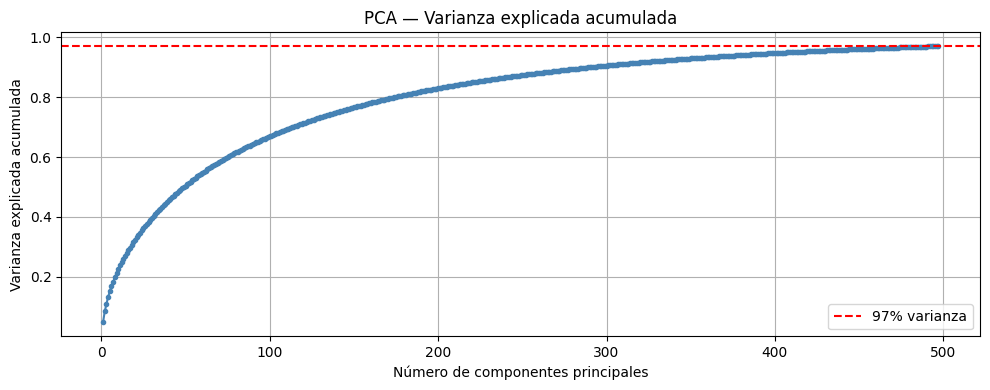

In [20]:
# ── Gráfica 1: Varianza explicada acumulada ───────────────────────
var_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(var_acumulada) + 1), var_acumulada, marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.97, color='red', linestyle='--', label='97% varianza')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza explicada acumulada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

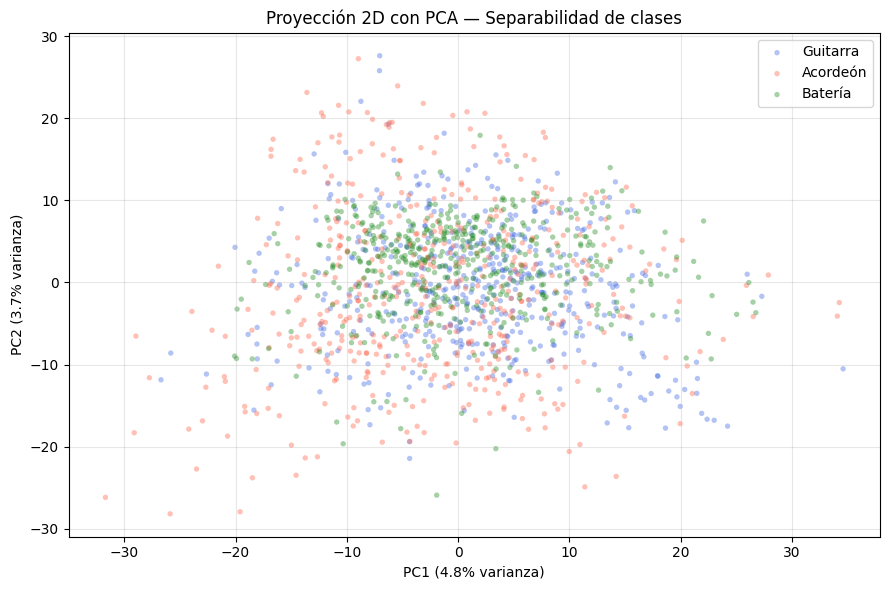

Las 2 componentes explican el 8.5% de la varianza total.
Si los grupos se ven separados en esta gráfica, KNN tendrá buen desempeño.


In [21]:
# ── Gráfica 2: Proyección 2D para visualizar separabilidad ────────
# Se usa un PCA de solo 2 componentes para poder graficar
pca_2d  = PCA(n_components=2, random_state=42)
X_2d    = pca_2d.fit_transform(X_escalado)

colores  = {0: 'royalblue', 1: 'tomato', 2: 'forestgreen'}
nombres  = {0: 'Guitarra',  1: 'Acordeón', 2: 'Batería'}

plt.figure(figsize=(9, 6))
for etiqueta, color in colores.items():
    mask = y == etiqueta
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=nombres[etiqueta],
                alpha=0.4, s=15, edgecolors='none')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proyección 2D con PCA — Separabilidad de clases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

var_total_2d = sum(pca_2d.explained_variance_ratio_) * 100
print(f"Las 2 componentes explican el {var_total_2d:.1f}% de la varianza total.")
print("Si los grupos se ven separados en esta gráfica, KNN tendrá buen desempeño.")

---
## Clasificación con KNN

### División de datos
Se usa 70% para entrenamiento y 30% para prueba, con `stratify=y` para garantizar que la proporción de cada clase sea igual en ambos conjuntos.

### ¿Por qué probar varios valores de k?
El valor de k controla cuántos vecinos vota para la clasificación. Un k muy pequeño (k=1) puede sobreajustarse al ruido; uno muy grande puede suavizar demasiado las fronteras. Se prueban 5 valores distintos para encontrar el óptimo.

In [22]:
# ── División 70/30 estratificada ──────────────────────────────────
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X_pca, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_entrenamiento.shape[0]} muestras")
print(f"Prueba:        {X_prueba.shape[0]} muestras")

Entrenamiento: 1050 muestras
Prueba:        450 muestras


In [23]:
# ── Probar 5 valores de k ─────────────────────────────────────────
valores_k    = [1, 3, 5, 7, 11]
resultados_k = []

print(f"{'k':>5} | {'Accuracy':>10} | {'Exactitud %':>12}")
print("-" * 35)

for k in valores_k:
    knn_k    = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_k.fit(X_entrenamiento, y_entrenamiento)
    y_pred_k = knn_k.predict(X_prueba)
    acc      = accuracy_score(y_prueba, y_pred_k)
    resultados_k.append((k, acc))
    print(f"{k:>5} | {acc:>10.4f} | {acc*100:>11.2f}%")

# Encontrar el mejor k
mejor_k, mejor_acc = max(resultados_k, key=lambda x: x[1])
print(f"\n→ Mejor k = {mejor_k} con accuracy = {mejor_acc*100:.2f}%")

    k |   Accuracy |  Exactitud %
-----------------------------------
    1 |     0.5733 |       57.33%
    3 |     0.5844 |       58.44%
    5 |     0.5911 |       59.11%
    7 |     0.5844 |       58.44%
   11 |     0.5756 |       57.56%

→ Mejor k = 5 con accuracy = 59.11%


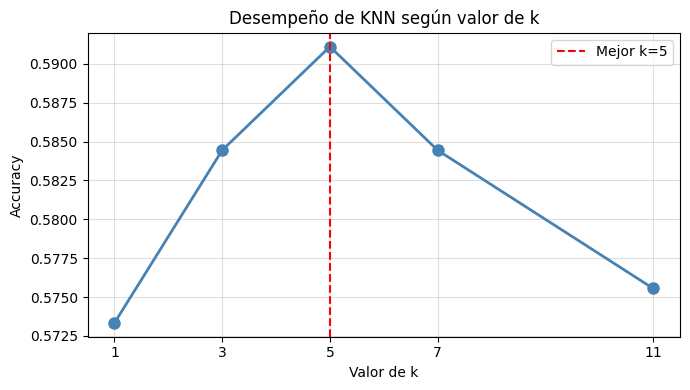

In [24]:
# ── Gráfica: Accuracy vs k ────────────────────────────────────────
ks   = [r[0] for r in resultados_k]
accs = [r[1] for r in resultados_k]

plt.figure(figsize=(7, 4))
plt.plot(ks, accs, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=mejor_k, color='red', linestyle='--', label=f'Mejor k={mejor_k}')
plt.xticks(ks)
plt.xlabel('Valor de k')
plt.ylabel('Accuracy')
plt.title('Desempeño de KNN según valor de k')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Evaluación del modelo

Se evalúa el modelo con el mejor k encontrado en la fase anterior. Se reportan:
- **Accuracy:** proporción de predicciones correctas sobre el total
- **Precision:** de los que el modelo dijo que eran clase X, ¿cuántos realmente lo eran?
- **Recall:** de los que realmente son clase X, ¿cuántos detectó el modelo?
- **F1-score:** media armónica entre precision y recall — útil cuando las clases están balanceadas
- **Matriz de confusión:** muestra qué clases se confunden entre sí

In [25]:
# ── Entrenar con el mejor k y evaluar ────────────────────────────
knn_final = KNeighborsClassifier(n_neighbors=mejor_k, metric='euclidean')
knn_final.fit(X_entrenamiento, y_entrenamiento)
y_pred = knn_final.predict(X_prueba)

exactitud = accuracy_score(y_prueba, y_pred)
print(f"Accuracy final (k={mejor_k}): {exactitud*100:.2f}%")
print()

# Reporte de clasificación
nombres_clases = ['Guitarra', 'Acordeón', 'Batería']
print("Reporte de clasificación:")
print(classification_report(y_prueba, y_pred, target_names=nombres_clases))

Accuracy final (k=5): 59.11%

Reporte de clasificación:
              precision    recall  f1-score   support

    Guitarra       0.53      0.72      0.61       150
    Acordeón       0.79      0.44      0.56       150
     Batería       0.57      0.61      0.59       150

    accuracy                           0.59       450
   macro avg       0.63      0.59      0.59       450
weighted avg       0.63      0.59      0.59       450



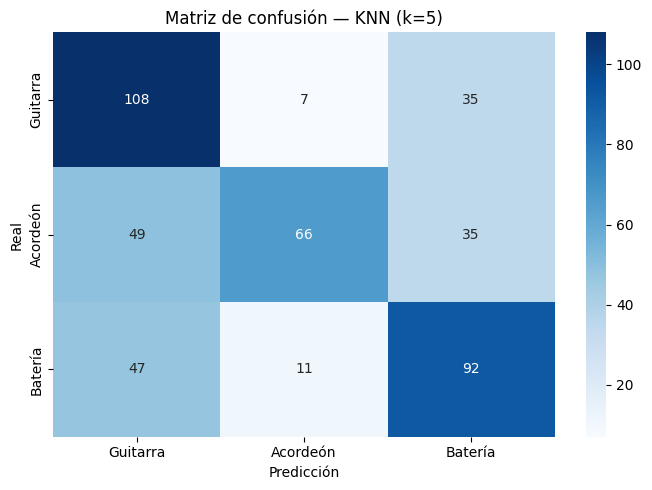

In [30]:
# ── Matriz de confusión ───────────────────────────────────────────
mc = confusion_matrix(y_prueba, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    mc,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title(f'Matriz de confusión — KNN (k={mejor_k})')
plt.tight_layout()
plt.show()

In [31]:
# ── Interpretación automática de la matriz de confusión ──────────
print("=" * 55)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 55)

for i, clase in enumerate(nombres_clases):
    total_real    = mc[i].sum()
    correctas     = mc[i][i]
    incorrectas   = total_real - correctas
    tasa          = correctas / total_real * 100

    print(f"\n{clase}:")
    print(f"  Correctamente clasificados: {correctas}/{total_real} ({tasa:.1f}%)")

    if incorrectas > 0:
        for j, otra in enumerate(nombres_clases):
            if i != j and mc[i][j] > 0:
                print(f"  Confundido con {otra}: {mc[i][j]} veces")

print("\n" + "=" * 55)
print("NOTA: Las confusiones entre clases pueden deberse a:")
print("  - Similitudes en forma o textura entre instrumentos")
print("  - Variedad de ángulos/fondos en las imágenes")
print("  - Audios grabados en condiciones o tonos similares")
print("=" * 55)

INTERPRETACIÓN DE RESULTADOS

Guitarra:
  Correctamente clasificados: 108/150 (72.0%)
  Confundido con Acordeón: 7 veces
  Confundido con Batería: 35 veces

Acordeón:
  Correctamente clasificados: 66/150 (44.0%)
  Confundido con Guitarra: 49 veces
  Confundido con Batería: 35 veces

Batería:
  Correctamente clasificados: 92/150 (61.3%)
  Confundido con Guitarra: 47 veces
  Confundido con Acordeón: 11 veces

NOTA: Las confusiones entre clases pueden deberse a:
  - Similitudes en forma o textura entre instrumentos
  - Variedad de ángulos/fondos en las imágenes
  - Audios grabados en condiciones o tonos similares
